# Experiment 1

### Develop a program to Load a dataset and select one numerical column. Compute mean, median, mode, standard deviation, variance, and range for a given numerical column in a dataset. Generate a histogram and boxplot to understand the distribution of the data. Identify any outliers in the data using IQR. Select a categorical variable from a dataset. Compute the frequency of each category and display it as a bar chart or pie chart

Dataset Loaded from Age_Fat.csv
Dataset Preview:
   Age  %Fat
0   23   7.8
1   23   9.5
2   27  17.8
3   27  25.9
4   39  26.5

Statistics for Numerical Column:
Mean: 46.44444444444444
Median: 51.0
Mode: 23
Standard Deviation: 13.218624215242327
Variance: 174.73202614379082
Range: 38


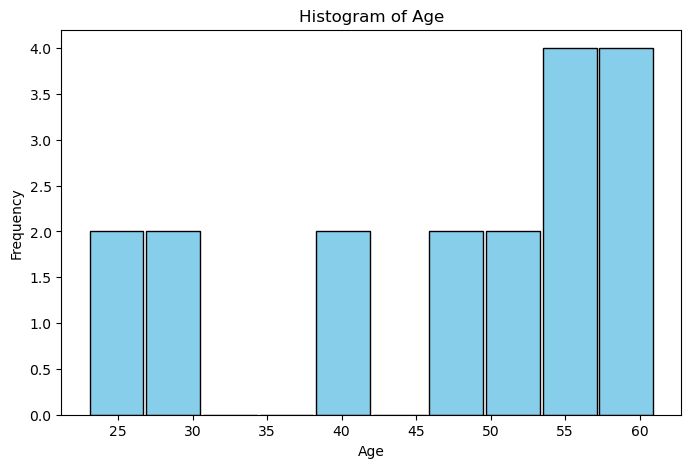

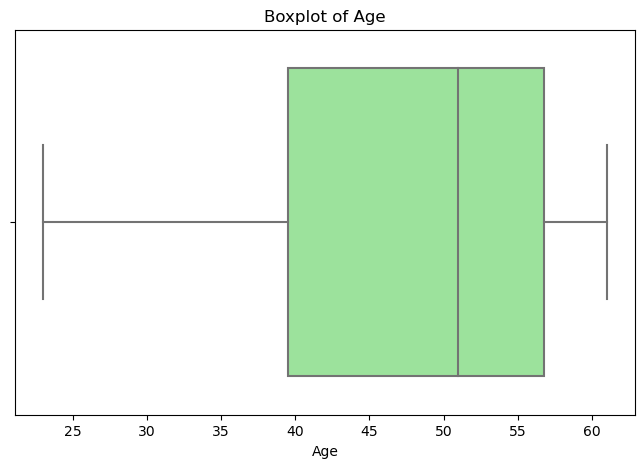


Outliers:
Series([], Name: Age, dtype: int64)

Category Frequencies:
Older          9
Middle-aged    5
Young          4
Name: Age Group, dtype: int64


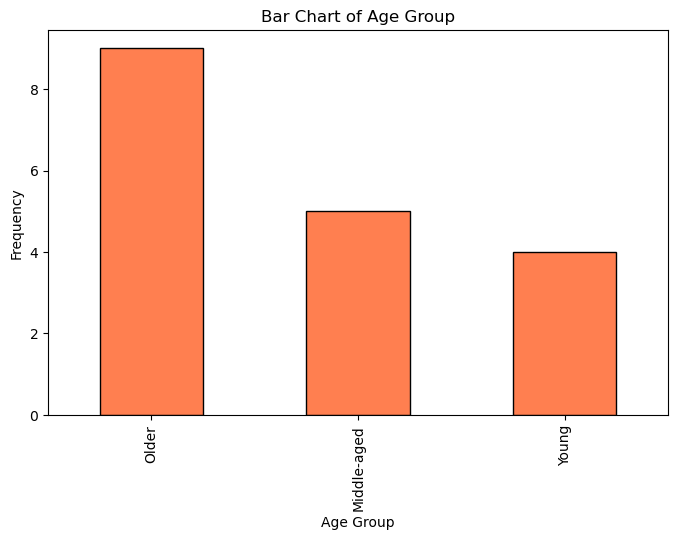

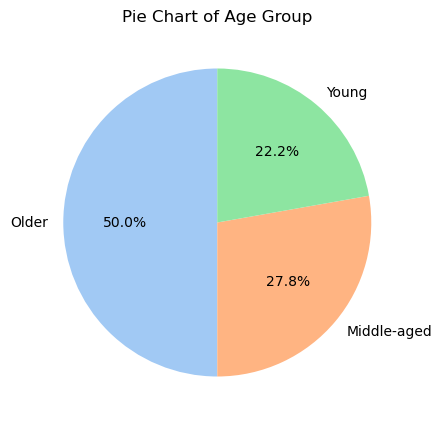

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create the dataset based on the provided data
data = pd.DataFrame({
    'Age': [23, 23, 27, 27, 39, 41, 47, 49, 50, 52, 54, 54, 56, 57, 58, 58, 60, 61],
    '%Fat': [7.8, 9.5, 17.8, 25.9, 26.5, 27.2, 27.4, 28.8, 30.2, 31.2, 31.4, 32.9, 33.4, 34.1, 34.6, 35.7, 41.2, 42.5]
})

# Save the dataset to a CSV file
data.to_csv('Age_Fat.csv', index=False)

# Load the dataset
print("Dataset Loaded from Age_Fat.csv")
data = pd.read_csv('Age_Fat.csv')

# Preview the dataset
print("Dataset Preview:")
print(data.head())

# Numerical column: %Fat
numerical_column = 'Age'#'%Fat'
data_num = data[numerical_column]

# Compute statistics
mean_val = data_num.mean()
median_val = data_num.median()
mode_val = data_num.mode()[0]
std_dev = data_num.std()
variance = data_num.var()
range_val = data_num.max() - data_num.min()

# Print statistics
print("\nStatistics for Numerical Column:")
print(f"Mean: {mean_val}")
print(f"Median: {median_val}")
print(f"Mode: {mode_val}")
print(f"Standard Deviation: {std_dev}")
print(f"Variance: {variance}")
print(f"Range: {range_val}")

# Generate a histogram
plt.figure(figsize=(8, 5))
plt.hist(data_num, bins=10, rwidth=0.95,color='skyblue', edgecolor='black')
plt.title(f"Histogram of {numerical_column}")
plt.xlabel(numerical_column)
plt.ylabel("Frequency")
plt.show()


# Generate a boxplot
plt.figure(figsize=(8, 5))#plt.figure(figsize=(8, 5))
sns.boxplot(x=data_num, color='lightgreen')
plt.title(f"Boxplot of {numerical_column}")
plt.show()

# Identify outliers using IQR
q1 = data_num.quantile(0.25)
q3 = data_num.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = data_num[(data_num < lower_bound) | (data_num > upper_bound)]

print("\nOutliers:")
print(outliers)

# Add a categorical column (Age Group) for demonstration purposes
def age_group(age):
    if age < 30:
        return 'Young'
    elif 30 <= age <= 50:
        return 'Middle-aged'
    else:
        return 'Older'

data['Age Group'] = data['Age'].apply(age_group)

# Categorical column: Age Group
categorical_column = 'Age Group'
data_cat = data[categorical_column]

# Compute frequency of each category
category_counts = data_cat.value_counts()

print("\nCategory Frequencies:")
print(category_counts)

# Bar chart for the categorical column
plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title(f"Bar Chart of {categorical_column}")
plt.xlabel(categorical_column)
plt.ylabel("Frequency")
plt.show()

# Pie chart for the categorical column
plt.figure(figsize=(8, 5))
category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title(f"Pie Chart of {categorical_column}")
plt.ylabel("")  # Remove y-axis label
plt.show()

2

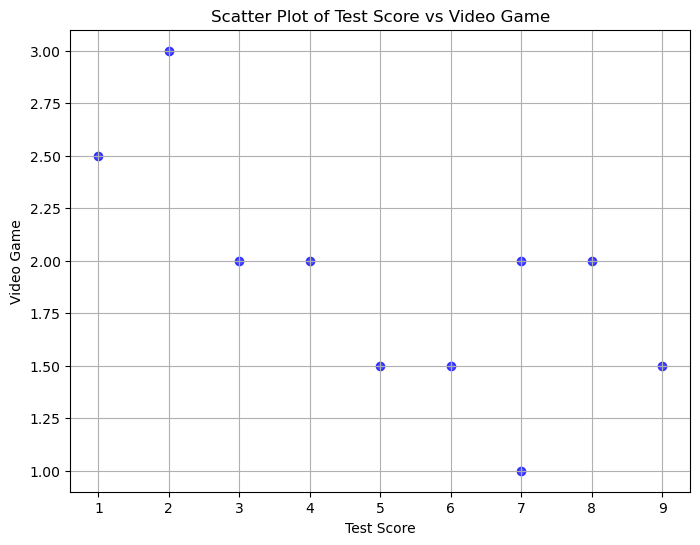

Pearson Correlation Coefficient (Test Score vs Video Game): -0.6847868181682677

Covariance Matrix:
[[ 7.06666667 -1.03333333]
 [-1.03333333  0.32222222]]

Correlation Matrix:
            Test Score  Video Game
Test Score    1.000000   -0.684787
Video Game   -0.684787    1.000000


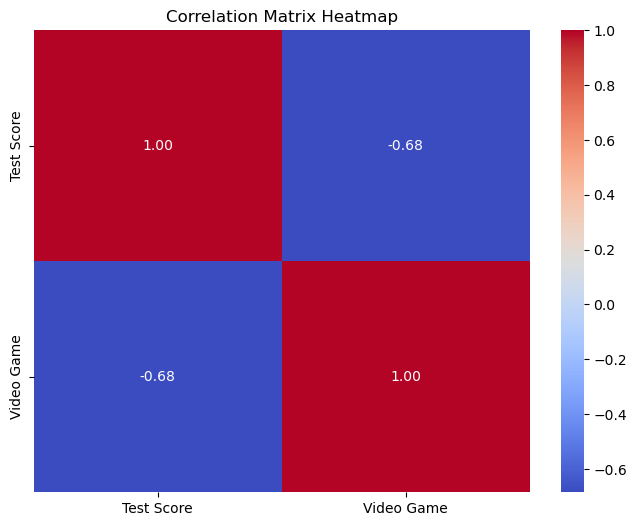

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (update 'your_dataset.csv' with your actual file path)
file_path = "Sample_Marks.csv"  # Replace with your dataset file path
df = pd.read_csv(file_path)

# Extract two columns (update 'Column1' and 'Column2' with actual column names)
column1 = "Test Score"  # Replace with the first column name
column2 = "Video Game"  # Replace with the second column name
selected_data = df[[column1, column2]]

# Scatter plot of the selected columns
plt.figure(figsize=(8, 6))
plt.scatter(selected_data[column1], selected_data[column2], color="blue", alpha=0.7)
plt.title(f"Scatter Plot of {column1} vs {column2}")
plt.xlabel(column1)
plt.ylabel(column2)
plt.grid(True)
plt.show()

# Calculate Pearson correlation coefficient
correlation_coefficient = np.corrcoef(selected_data[column1], selected_data[column2])[0, 1]
print(f"Pearson Correlation Coefficient ({column1} vs {column2}): {correlation_coefficient}")

# Compute covariance matrix
cov_matrix = np.cov(selected_data[column1], selected_data[column2])
print("\nCovariance Matrix:")
print(cov_matrix)

# Compute correlation matrix
correlation_matrix = selected_data.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

LWR

Predicted Tip for a total bill of $30: 3.99


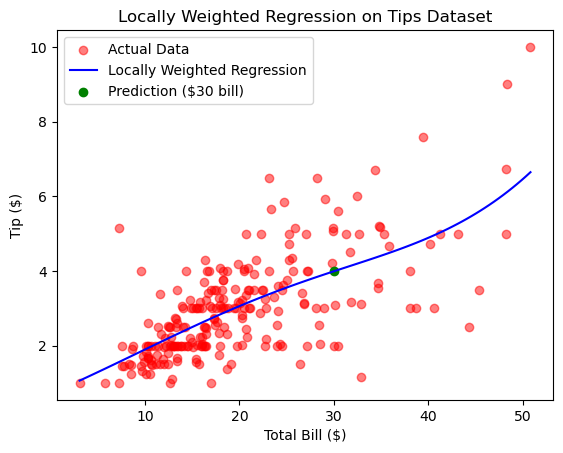

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset from CSV file
file_path = "10-dataset.csv"  # Update this with the actual path to your CSV file
tips = pd.read_csv(file_path)

# Use total_bill as feature (X) and tip as target (y)
X = tips["total_bill"].values
y = tips["tip"].values

# Locally Weighted Regression Function
def locally_weighted_regression(x_query, X, y, tau):
    m = len(X)
    weights = np.exp(-((X - x_query) ** 2) / (2 * tau ** 2))  # Compute weights
    
    # Create weighted linear regression
    X_b = np.c_[np.ones(m), X]  # Add bias term (column of ones)
    W = np.diag(weights)  # Create diagonal weight matrix
    
    # Solve for theta using normal equation: theta = (X^T W X)^-1 X^T W y
    #theta = np.linalg.inv(X_b.T @ W @ X_b) @ (X_b.T @ W @ y)
    theta = np.linalg.pinv(X_b.T @ W @ X_b) @ (X_b.T @ W @ y)
    
    # Predict tip for x_query
    x_query_b = np.array([1, x_query])
    return x_query_b @ theta

# Predicting tip for a total bill of $30
tau = 10  # Bandwidth (adjust as needed)
x_query = 30
predicted_tip = locally_weighted_regression(x_query, X, y, tau)
print(f"Predicted Tip for a total bill of $30: {predicted_tip:.2f}")

# Plot the results
X_range = np.linspace(X.min(), X.max(), 100)
y_pred = np.array([locally_weighted_regression(x, X, y, tau) for x in X_range])

plt.scatter(X, y, color='red', alpha=0.5, label="Actual Data")
plt.plot(X_range, y_pred, color='blue', label="Locally Weighted Regression")
plt.scatter([x_query], [predicted_tip], color='green', marker='o', label="Prediction ($30 bill)")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.legend()
plt.title("Locally Weighted Regression on Tips Dataset")
plt.show()

KNN

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the Iris dataset from a CSV file
file_path = 'iris.csv'  # Replace with the path to your CSV file
df = pd.read_csv(file_path)

# Separate features (X) and labels (y)
X = df.iloc[:, :-1].values  # All columns except the last one
y = df.iloc[:, -1].values   # The last column (species)

# Convert species labels to numerical values (if necessary)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Function to evaluate k-NN for different values of k
def evaluate_knn(X_train, X_test, y_train, y_test, k_values, weighted=False):
    results = {}
    for k in k_values:
        if weighted:
            knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
        else:
            knn = KNeighborsClassifier(n_neighbors=k)
        
        # Train the model
        knn.fit(X_train, y_train)
        
        # Make predictions
        y_pred = knn.predict(X_test)
        
        # Evaluate the model
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        conf_matrix = confusion_matrix(y_test, y_pred)
        results[k] = {'accuracy': accuracy, 'f1_score': f1, 'conf_matrix': conf_matrix}
    
    return results

# Test for different values of k
k_values = [1, 3, 5]

# Evaluate regular k-NN
regular_knn_results = evaluate_knn(X_train, X_test, y_train, y_test, k_values, weighted=False)
print("Regular k-NN Results:")
for k, metrics in regular_knn_results.items():
    print(f"\nk={k}: Accuracy={metrics['accuracy']:.4f}, F1-Score={metrics['f1_score']:.4f}")
    print("Confusion Matrix:")
    print(metrics['conf_matrix'])

# Evaluate weighted k-NN
weighted_knn_results = evaluate_knn(X_train, X_test, y_train, y_test, k_values, weighted=True)
print("\nWeighted k-NN Results:")
for k, metrics in weighted_knn_results.items():
    print(f"\nk={k}: Accuracy={metrics['accuracy']:.4f}, F1-Score={metrics['f1_score']:.4f}")
    print("Confusion Matrix:")
    print(metrics['conf_matrix'])

PCA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the dataset from CSV file
df = pd.read_csv('iris.csv')  # Replace 'dataset.csv' with your actual file name

# Display the first few rows of the dataset to understand its structure
print("Dataset preview:")
print(df.head())

# Assuming the last column is the target variable
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values  # Labels

# Standardize the data (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce dimensionality to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Get unique labels for coloring
unique_labels = np.unique(y)

# Plot the PCA-reduced data
plt.figure(figsize=(8, 6))
for target in unique_labels:
    plt.scatter(X_pca[y == target, 0], X_pca[y == target, 1], label=target, alpha=0.7)

# Print the shape of the original and reduced datasets
print("\n\nOriginal dataset shape:", X_scaled.shape)  # Before PCA
print("Reduced dataset shape:", X_pca.shape)  # After PCA

plt.title('PCA of Dataset (Reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)

# L regrassion

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load dataset
data = pd.read_csv("BostonHousing.csv")  

# Select one feature and target
X = data[['rm']]      # Average number of rooms
y = data['medv']       # Median home value

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Plot
plt.scatter(X_test, y_test, color='blue', label='Actual Prices', alpha = 0.6)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median Value of Homes (MEDV)")
plt.title("Linear Regression: RM vs MEDV")
plt.legend()
plt.grid(True)
plt.show()

# Poly nominal

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv("auto-mpg.csv") 

# Clean the 'horsepower' column
data.replace({'horsepower': {'?': np.nan}}, inplace=True)
data.dropna(subset=['horsepower'], inplace=True)
data['horsepower'] = data['horsepower'].astype(float)

# Select features and target
X = data[['horsepower']]
y = data['mpg']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial transformation (degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict
y_pred = model.predict(X_test_poly)

# Plot
plt.scatter(X_test, y_test, color='green', label='Actual MPG',alpha = 0.6)
sorted_idx = X_test['horsepower'].argsort()
plt.plot(X_test.iloc[sorted_idx], y_pred[sorted_idx], color='orange', label='Polynomial Fit')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression: Horsepower vs MPG")
plt.legend()
plt.grid(True)
plt.show()

# DecisionTree_Consider

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Step 1: Load dataset
file_path = 'titanic.csv'  
df = pd.read_csv(file_path)

# Step 2: Preprocess data (cleaning and encoding)
# Keep only required columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

# Drop rows with any missing values in the selected columns
df.dropna(subset=['Survived', 'Pclass', 'Sex', 'Age', 'Fare'], inplace=True)

# Convert 'Sex' to numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Define features and label
X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train the Decision Tree Classifier
#clf = DecisionTreeClassifier(random_state=42)    
clf = DecisionTreeClassifier(random_state=42, max_depth=3)
clf.fit(X_train, y_train)

# Step 5: Visualize the decision tree
plt.figure(figsize=(20, 12))  #(Width, Height), Larger figure for clarity
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=["Not Survived", "Survived"], 
          filled=True, 
          rounded=True,
          fontsize=12)
plt.title("Decision Tree - Titanic Survival Prediction\n\n", fontsize=16)
plt.show()

# Step 6: Evaluate the model
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# Naive Bayesian

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Step 1: Read the CSV file
data = pd.read_csv('iris.csv')

# Step 2: Separate features and target
# Assuming the last column is the target (species)
X = data.iloc[:, :-1]  # all rows, all columns except the last
y = data.iloc[:, -1]   # all rows, last column

# Step 3: Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Train the Naive Bayes classifier
model = GaussianNB()
model.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = model.predict(X_test)

# Step 6: Compute the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Naive Bayes Classifier: {accuracy * 100:.2f}%")


# Wisconsin Breast Cancer

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mode

# === Step 1: Read CSV file from device ===
df = pd.read_csv("Breast Cancer Wisconsin.csv")

# === Step 2: Preprocess the dataset ===
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

if 'diagnosis' in df.columns:
    diagnosis = df['diagnosis'].map({'M': 1, 'B': 0})  # 1: Malignant, 0: Benign
    df = df.drop(columns=['diagnosis'])
else:
    diagnosis = None

# === Step 3: Standardize features ===
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# === Step 4: Apply K-Means Clustering ===
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(scaled_data)
labels = kmeans.labels_

# === Step 5: PCA for Visualization ===
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# === Step 5.1: Prepare data for plotting ===
vis_df = pd.DataFrame({
    'PCA1': pca_data[:, 0],
    'PCA2': pca_data[:, 1],
    'Cluster': labels
})

if diagnosis is not None:
    vis_df['Actual'] = diagnosis
    
    # Map cluster numbers to label names based on majority
    cluster_map = {}
    for cluster in [0, 1]:
        majority = mode(diagnosis[labels == cluster], keepdims=True).mode[0]
        cluster_map[cluster] = 'Predicted Malignant' if majority == 1 else 'Predicted Benign'
        
    vis_df['Cluster_Label'] = vis_df['Cluster'].map(cluster_map)
    
    # Map actual labels to strings
    vis_df['Actual_Label'] = vis_df['Actual'].map({1: 'Actual Malignant', 0: 'Actual Benign'})

# === Step 6: Plotting with Legend ===
plt.figure(figsize=(10, 6))

# First plot predicted cluster (colored)
sns.scatterplot(
    data=vis_df,
    x='PCA1', y='PCA2',
    hue='Cluster_Label',
    palette={'Predicted Malignant': 'red', 'Predicted Benign': 'blue'},
    s=100,
    alpha=0.6,
    legend='full'
)

# Then plot actual values (shapes in black)
sns.scatterplot(
    data=vis_df,
    x='PCA1', y='PCA2',
    style='Actual_Label',
    markers={'Actual Malignant': 'X', 'Actual Benign': 'o'},
    color='black',
    s=50,
    alpha=0.5,
    legend='brief'
)

plt.title("K-Means Clustering on Breast Cancer Dataset (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
